In [253]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, recall_score, roc_auc_score, roc_curve

In [2]:
pd.set_option('display.max_columns', None)

In [256]:
# df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv')
# test_data = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/test.csv')

## Load Dataset

In [3]:
df = pd.read_csv("train.csv")
df.shape

(594194, 21)

In [258]:
df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [259]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  str    
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  str    
 4   Dependents        594194 non-null  str    
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  str    
 7   MultipleLines     594194 non-null  str    
 8   InternetService   594194 non-null  str    
 9   OnlineSecurity    594194 non-null  str    
 10  OnlineBackup      594194 non-null  str    
 11  DeviceProtection  594194 non-null  str    
 12  TechSupport       594194 non-null  str    
 13  StreamingTV       594194 non-null  str    
 14  StreamingMovies   594194 non-null  str    
 15  Contract          594194 non-null  str    
 16  PaperlessBilling  594194 non-nu

In [260]:
df.isnull().sum()

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [4]:
object_cols = df.select_dtypes(include='object').columns
object_cols

/var/folders/gx/5977vg1j77q10smlkkwzkw4m0000gn/T/ipykernel_8531/4015107672.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df.select_dtypes(include='object').columns


Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='str')

In [5]:
num_cols = df.select_dtypes(exclude='object').columns
num_cols

Index(['id', 'SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')

In [6]:
categorical_columns = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',\
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',\
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',\
       'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen']

numerical_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']
#numerical_columns = ['MonthlyCharges', 'TotalCharges']

target_column = ["Churn"]

### lets check target column distribution

In [7]:
churn_dist = df["Churn"].value_counts().to_frame()
churn_dist["percentage"] = (churn_dist["count"]/ df.shape[0]*100).round(2)
churn_dist

,count,percentage
Churn,,
No,460377,77.48
Yes,133817,22.52


In [265]:
print(f"Churn Ration:\nChurn: No Churn = {churn_dist["percentage"].iloc[1]/churn_dist["percentage"].iloc[1]}: {(churn_dist["percentage"].iloc[0]/ churn_dist["percentage"].iloc[1]).round(2)}")

Churn Ration:
Churn: No Churn = 1.0: 3.44


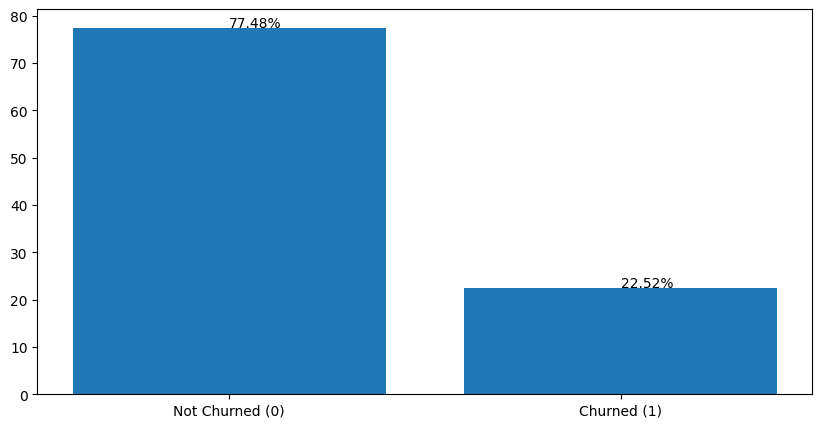

In [266]:
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(['Not Churned (0)', 'Churned (1)'], churn_dist["percentage"])
for i, col in enumerate(churn_dist["percentage"]):
    ax.text(i, col+0.05, f"{col}%")



#### Target distribution is imbalance, churn to no churn ratio is 1:3.44. Need to consider this during training the model

# Numerical column analysis - Univariate and Bivariant 

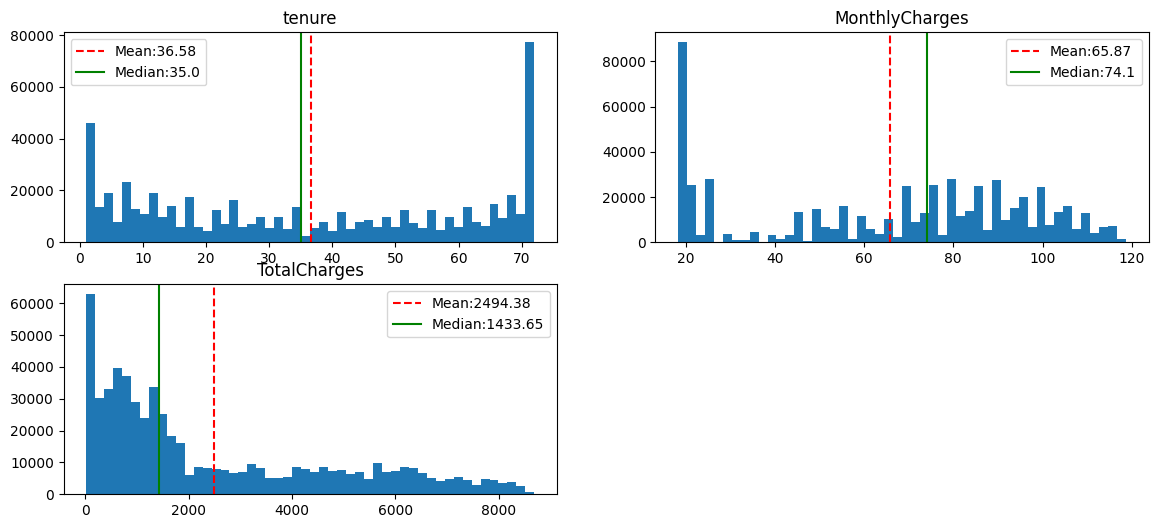

In [267]:
fig, axes = plt.subplots(2,2, figsize = (14,6))
axes = axes.flatten()
for i, col in enumerate(numerical_columns):
    axes[i].hist(df[col], bins = 50)

    mean = (df[col].mean()).round(2)
    median = (df[col].median()).round(2)

    axes[i].axvline(mean, color = 'red', linestyle="--", label=f"Mean:{mean}")
    axes[i].axvline(median, color='green', linestyle = "-", label = f"Median:{median}")

    axes[i].set_title(col)
    axes[i].legend()

for j in range(len(numerical_columns), len(axes)):
    axes[j].set_visible(False)


#### Check for outliers

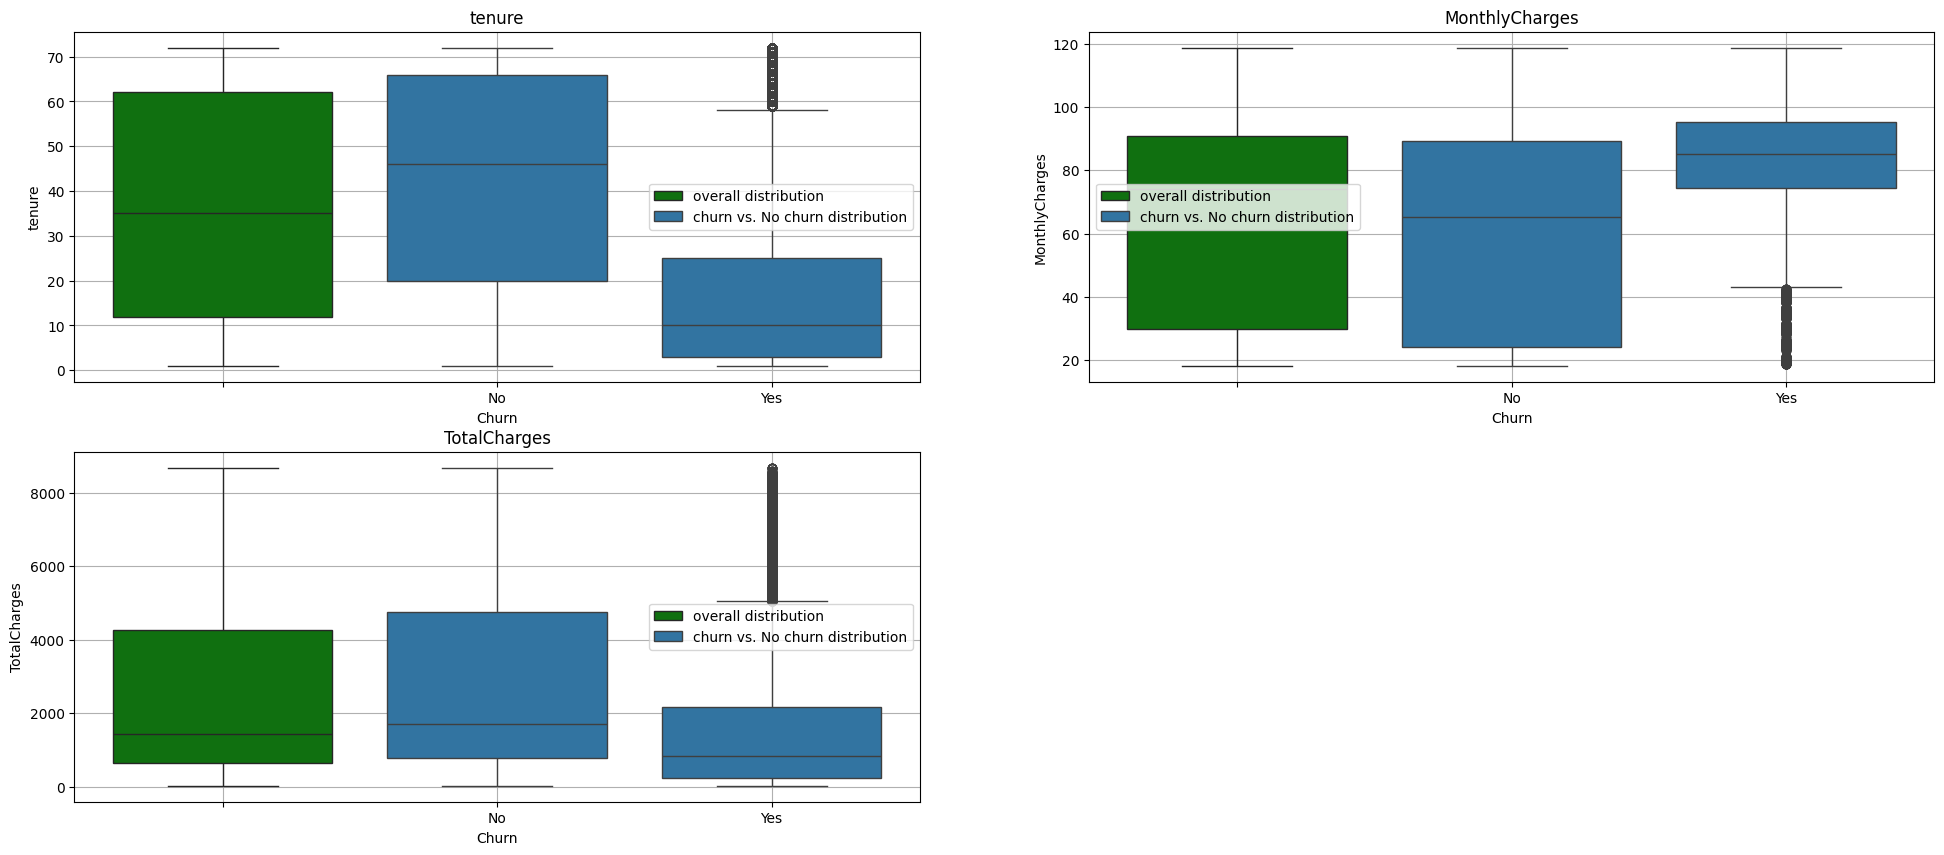

In [268]:
fig, axes = plt.subplots(2,2, figsize = (24,10))
axes = axes.flatten()
for i, col in enumerate(numerical_columns):
    sns.boxplot(df[col], ax=axes[i], color="green", label="overall distribution")
    sns.boxplot(data=df, x="Churn", y=col, ax=axes[i], label = "churn vs. No churn distribution")
    
    axes[i].set_title(col)
    axes[i].grid()
    axes[i].plot()
    axes[i].legend()

for j in range(len(numerical_columns), len(axes)):
    axes[j].set_visible(False)

#sns.boxplot(df[col])


In [269]:
churned = df[df["Churn"] == 'Yes']
not_churned = df[df["Churn"] == 'No']

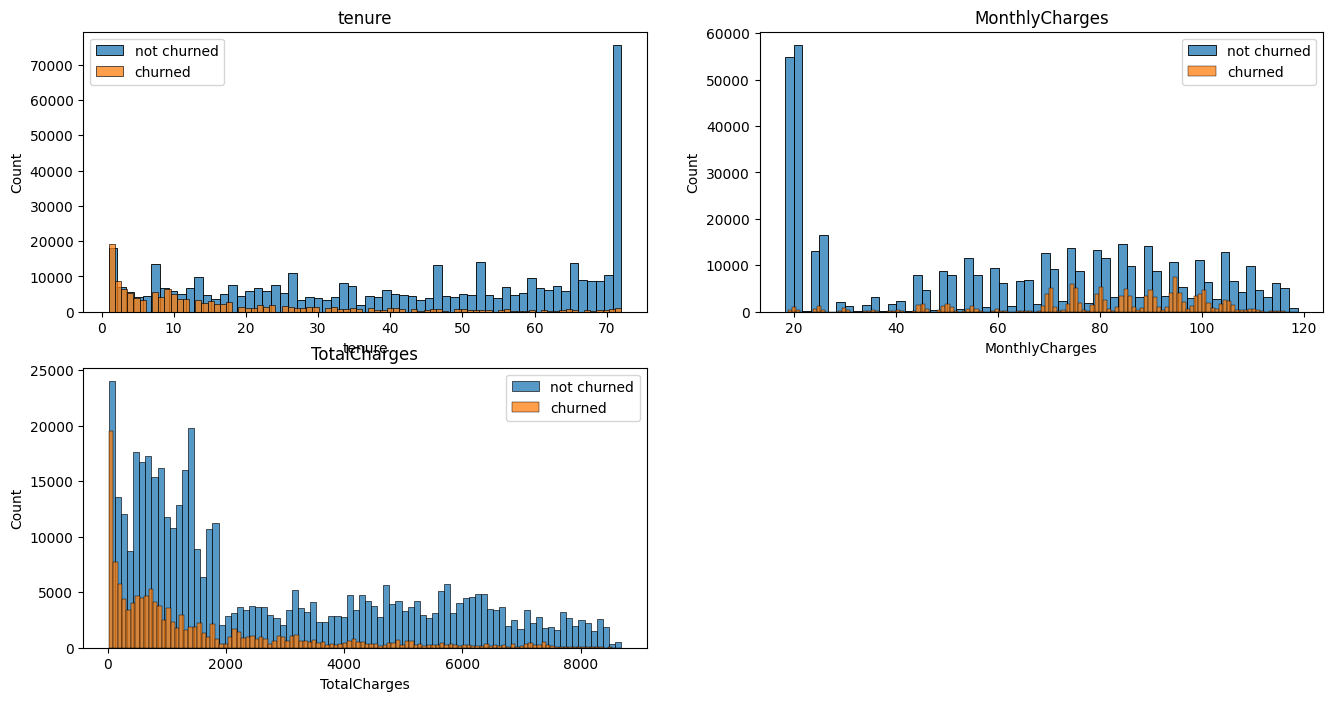

In [270]:
fig, axes = plt.subplots(2,2,figsize=(16,8))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.histplot(not_churned[col], ax= axes[i], label = "not churned")
    sns.histplot(churned[col], ax=axes[i], label = "churned")

    axes[i].set_title(col)
    axes[i].legend()

for j in range(len(numerical_columns), len(axes)):
    axes[j].set_visible(None)

<Figure size 1600x1200 with 0 Axes>

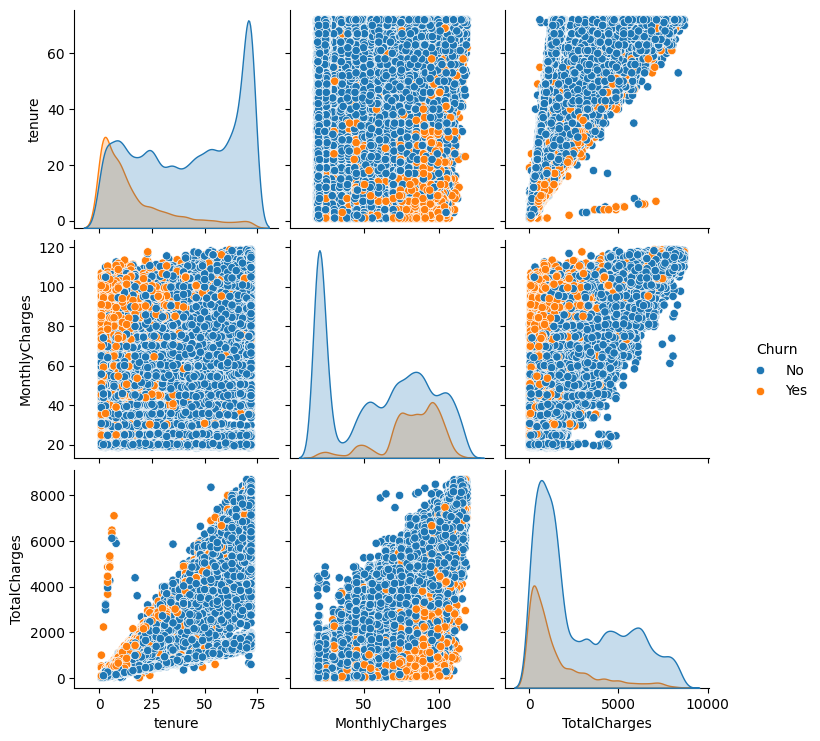

In [271]:
plt.figure(figsize = (16,12))
sns.pairplot(df.sample(frac=0.1)[numerical_columns+ target_column], hue="Churn")

- For "monthlycharge" and "totalcharges" there is significance difference in mean and median, that means these 2 are skewed.
- All 3 numerical columns contains significant number of outliers for Churned customers. there is no outliers for not churned.
- As tenure increases churn rate decreases. same for "Total charges".
- not much relationships between the numeric columns

## Categorical Columns

In [272]:
categorical_columns

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'SeniorCitizen']

### Distribution of Categorical columns

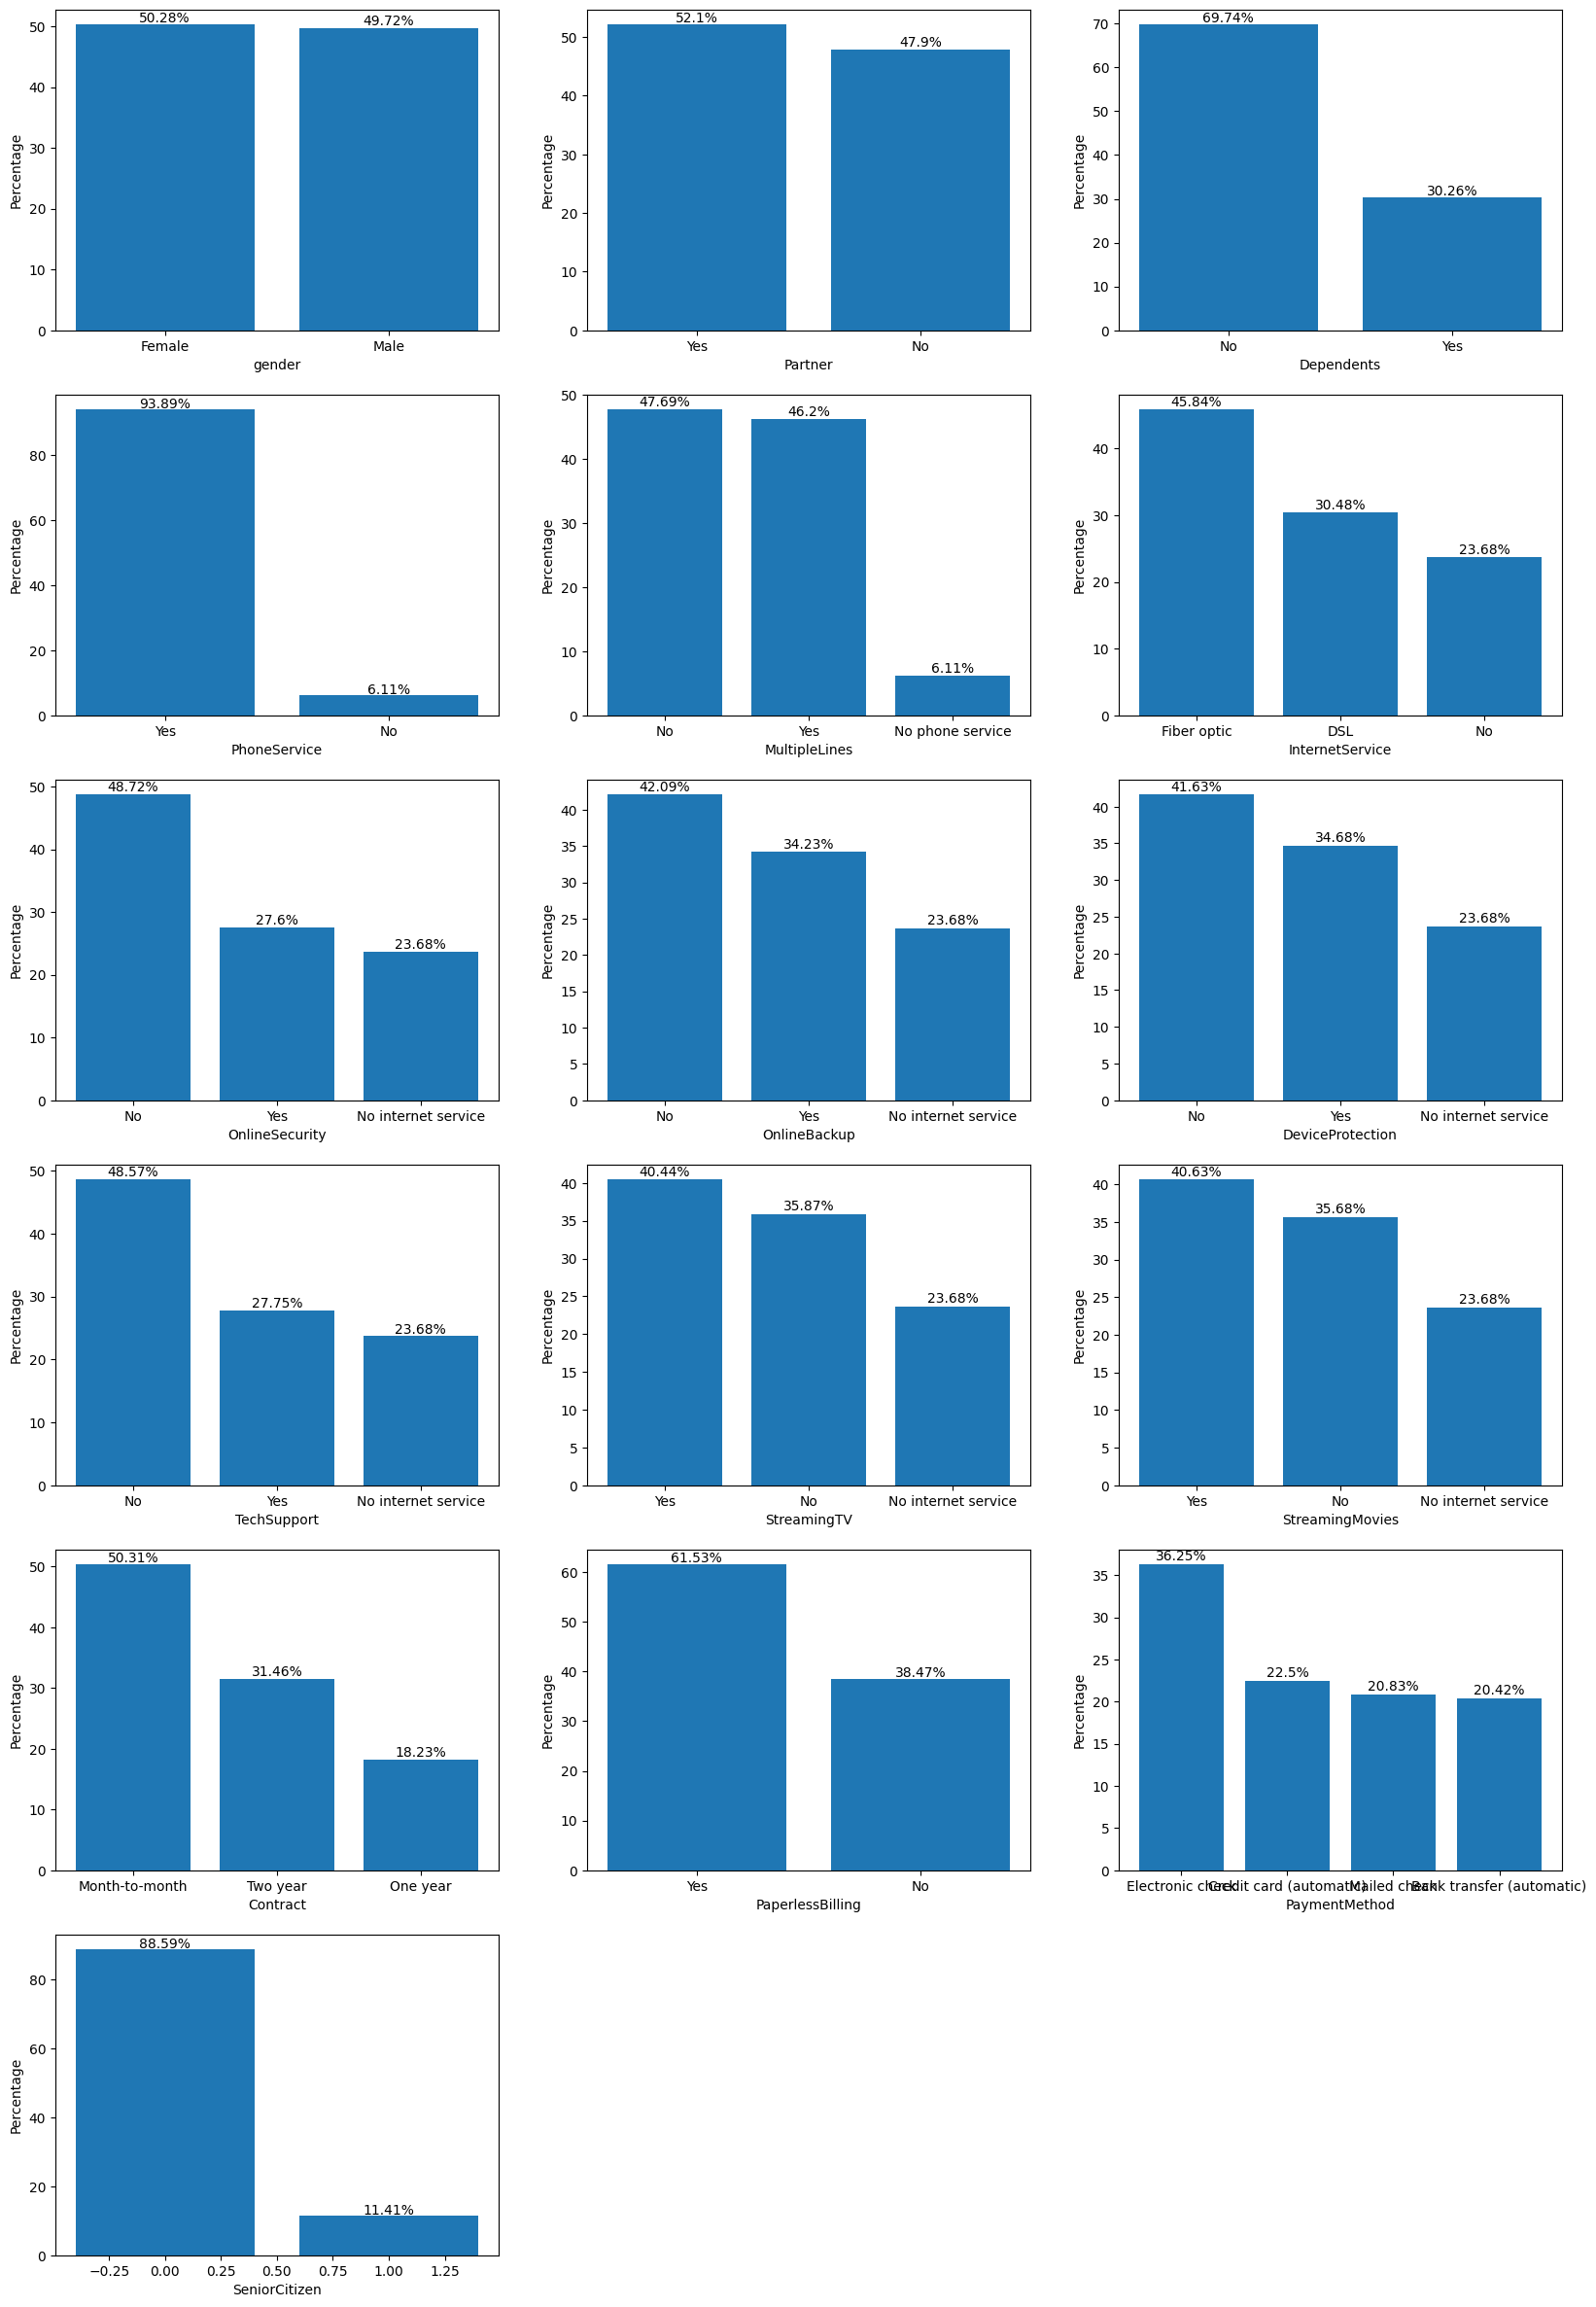

In [273]:
fig, axes = plt.subplots(6,3, figsize=(20,30))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
    value_counts = (df[col].value_counts(normalize=True)*100).round(2)
    axes[i].bar(value_counts.index, value_counts.values)

    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Percentage")

    for x, y in zip(value_counts.index, value_counts.values):
        axes[i].text(x, y+0.5, f"{y}%", ha="center")
    
    for j in range(len(categorical_columns), len(axes)):
        axes[j].set_visible(None)



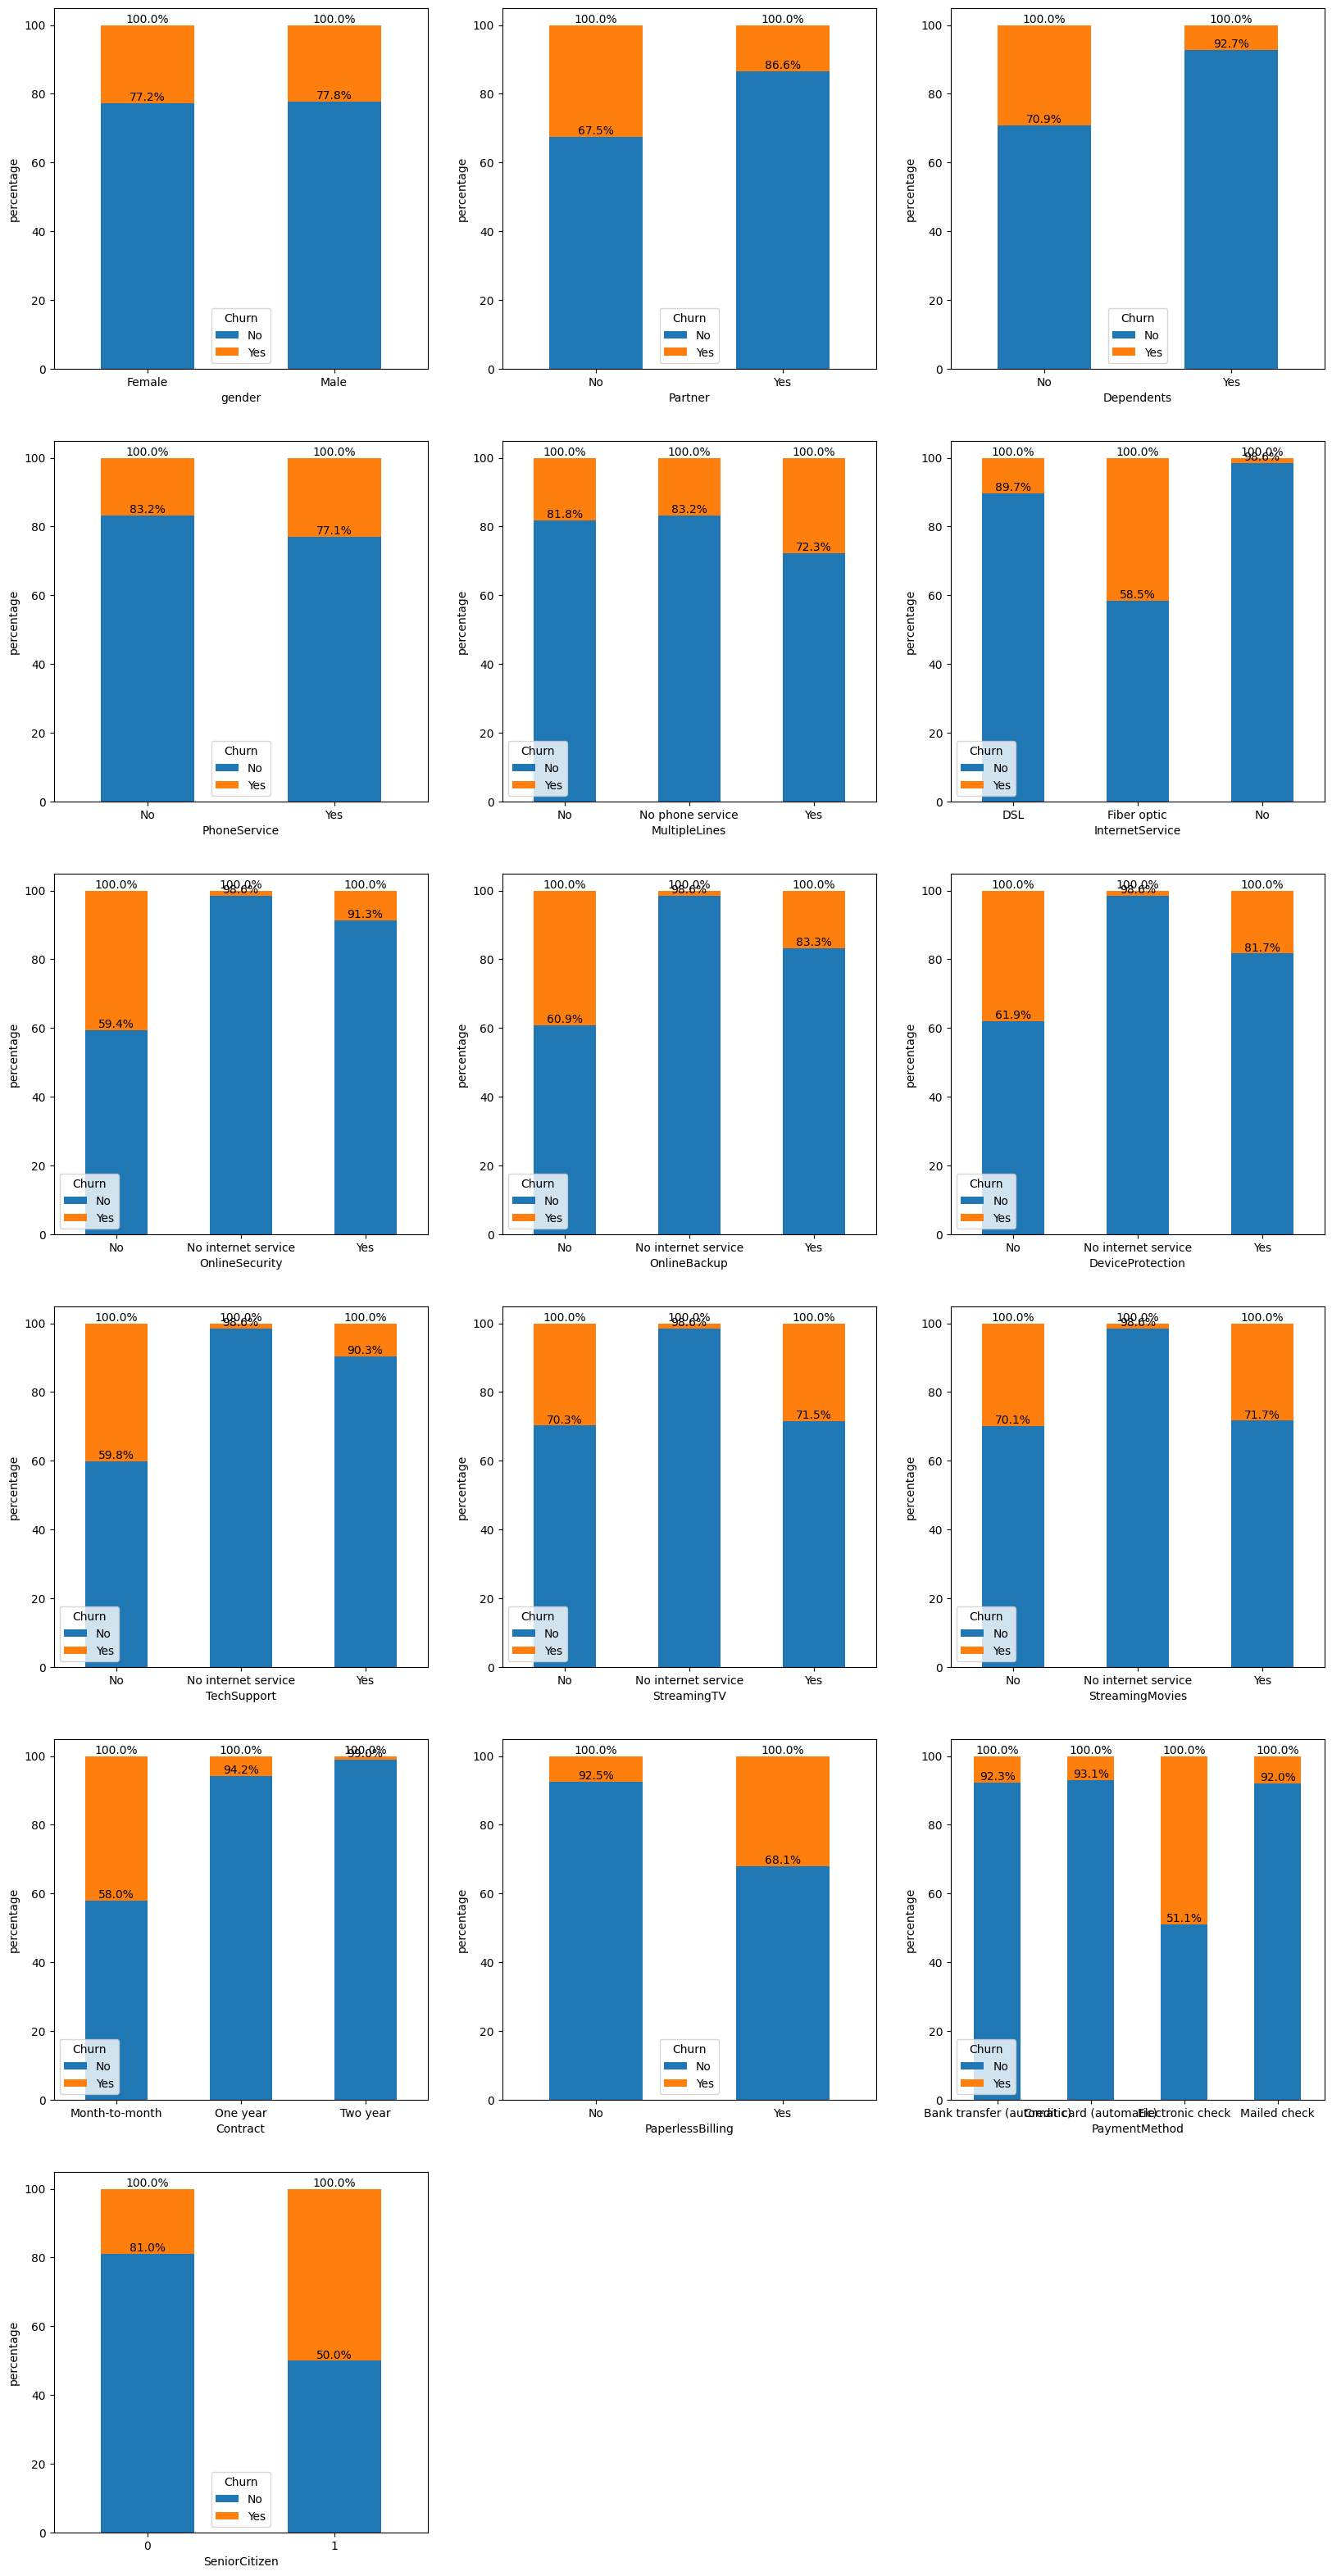

In [274]:
fig, axes = plt.subplots(6,3, figsize = (20,40))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
    churn_distribution = (pd.crosstab(df[col], df["Churn"], normalize="index")*100).round(2)
    churn_distribution.plot(kind='bar', stacked=True, ax=axes[i])

    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.1f%%')

    axes[i].tick_params(axis = 'x', rotation=0)
    axes[i].set_ylabel("percentage")

for j in range(len(categorical_columns), len(axes)):
    axes[j].set_visible(None)

### Looks Churn rate does not depend on gender, churn rate depends on all other categorical columns

## Featurn Engineering

In [275]:
df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [276]:
#df["is_monthly_contract"] = np.where(df["Contract"] == "Month-to-month", 1, 0)

In [277]:
# val = df["is_monthly_contract"].value_counts()
# cross = (pd.crosstab(df["is_monthly_contract"], df["Churn"], normalize=True)*100).round(2)
# cross.plot(kind='bar')


In [278]:
# df["PaymentMethod"].value_counts()
# PaymentMethod_churn = (pd.crosstab(df["PaymentMethod"], df["Churn"], normalize=True)*100).round(2)
# PaymentMethod_churn.plot(kind='bar')

In [279]:
#df["InternetService"].value_counts()

In [24]:
def feature_eng_df(data):

        #create new features
        data["monthly_spent"] = data["TotalCharges"] / data["tenure"]

        data["tenure_group"] = pd.cut(
        data["tenure"],
        bins=[0,12,24,36,48,60,72,84],
        labels=["0-12", "13-24", "25-36", "37-48","49-60", "61-72", "70+"]
        )

        median_monthly_spent = data["monthly_spent"].median()
        print(median_monthly_spent)
        data["if_high_spender"] = (data["monthly_spent"] > median_monthly_spent).astype('int')

        #aggregate all the services
        services = ['PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
                'DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
        for col in services:
                classes_ = data[col].unique()
                data[col] = np.where(data[col] == classes_[0],0,1)
        data["total_services"] = data[services].sum(axis=1) 

        data['has_family'] = ((data['Partner'] == 'Yes') | (data['Dependents'] == 'Yes')).astype(int)
        data['senior_alone'] = ((data['SeniorCitizen'] == 1) & (data['Dependents'] == 'No')).astype(int)

        #identify if monthly contract
        data["is_monthly_contract"] = np.where(data["Contract"] == "Month-to-month", 1, 0)
        data["is_electronic_check"] = np.where(data["PaymentMethod"] == "Electronic check", 1, 0)
        data["is_fiber_optics"] = np.where(data["InternetService"] == "Fiber optic", 1, 0)

        

        binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]
        for col in binary_cols:
            classes_ = np.unique(data[col])
            data[col] = np.where(data[col] == classes_[0], 0, 1)

        return data



In [281]:
classes_ = np.unique(df["Churn"])
df["Churn"] = np.where(df["Churn"] == classes_[0], 0, 1)

In [9]:
df = feature_eng_df(df)

73.36666666666666


In [283]:
df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,monthly_spent,tenure_group,if_high_spender
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,0,57.029310,25-36,0
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,0,65.141379,49-60,0
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,0,100.712931,49-60,1
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,1,70.700000,0-12,0
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,1,70.450000,0-12,0


In [10]:
df.corr(numeric_only=True)["Churn"].sort_values(ascending=False)

Churn                  1.000000
is_electronic_check    0.476255
is_monthly_contract    0.470500
is_fiber_optics        0.418819
PaperlessBilling       0.285107
if_high_spender        0.278091
MonthlyCharges         0.272997
senior_alone           0.239141
monthly_spent          0.237802
SeniorCitizen          0.236362
OnlineSecurity         0.204544
TechSupport            0.191011
MultipleLines          0.098033
DeviceProtection       0.074228
id                    -0.012971
total_services        -0.026122
PhoneService          -0.034843
StreamingTV           -0.129296
StreamingMovies       -0.132118
TotalCharges          -0.218365
Partner               -0.228212
has_family            -0.236086
Dependents            -0.240369
OnlineBackup          -0.338409
tenure                -0.418453
Name: Churn, dtype: float64

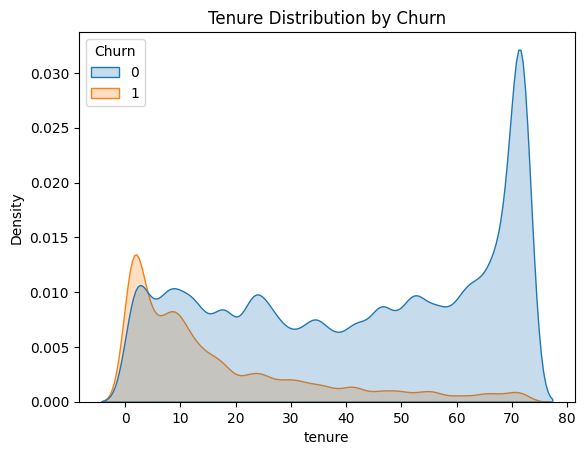

In [285]:

sns.kdeplot(data=df, x="tenure", hue="Churn", fill=True)

plt.title("Tenure Distribution by Churn")
plt.show()

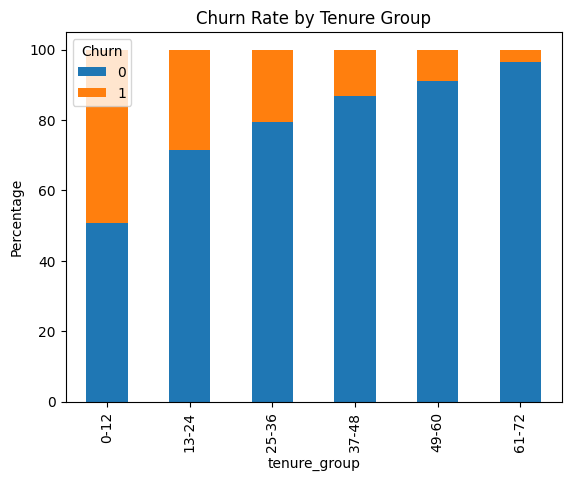

In [286]:
tenure_churn = pd.crosstab(df["tenure_group"], df["Churn"], normalize="index") * 100

tenure_churn.plot(kind="bar", stacked=True)

plt.title("Churn Rate by Tenure Group")
plt.ylabel("Percentage")
plt.show()

In [12]:
categorical_columns = ['gender', 'Partner', 'Dependents', 'InternetService', 'Contract',\
       'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen', 'tenure_group', 'if_high_spender', \
       'has_family', 'senior_alone', 'is_monthly_contract', 'is_electronic_check', 'is_fiber_optics']

numerical_columns = ['MonthlyCharges', 'TotalCharges', 'monthly_spent', "total_services", 'tenure']

# categorical_columns = ['gender', 'Partner', 'Dependents', 'InternetService', 'Contract',\
#        'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen', 'tenure_group','if_high_spender']

# numerical_columns = ['MonthlyCharges', 'TotalCharges', 'monthly_spent','tenure']

In [13]:
df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,monthly_spent,tenure_group,if_high_spender,total_services,has_family,senior_alone,is_monthly_contract,is_electronic_check,is_fiber_optics
0,0,Male,0,1,1,29,0,0,DSL,0,0,0,0,0,0,One year,1,Mailed check,60.10,1653.85,0,57.029310,25-36,0,0,1,0,0,0,0
1,1,Male,0,1,1,58,0,0,DSL,0,1,1,0,1,0,Two year,0,Credit card (automatic),69.50,3778.20,0,65.141379,49-60,0,3,1,0,0,0,0
2,2,Male,0,1,0,58,0,1,Fiber optic,1,1,1,1,1,1,Month-to-month,1,Electronic check,100.40,5841.35,0,100.712931,49-60,1,7,1,0,1,1,1
3,3,Female,0,0,0,1,0,0,Fiber optic,1,0,1,1,0,0,Month-to-month,1,Electronic check,69.70,70.70,1,70.700000,0-12,0,3,0,0,1,1,1
4,4,Female,0,0,0,1,0,0,Fiber optic,1,0,1,1,0,0,Month-to-month,1,Electronic check,70.45,70.45,1,70.450000,0-12,0,3,0,0,1,1,1


In [14]:
X = df[categorical_columns+numerical_columns]
y = df["Churn"]

In [290]:
X.head()

,gender,Partner,Dependents,InternetService,Contract,PaperlessBilling,PaymentMethod,SeniorCitizen,tenure_group,if_high_spender,MonthlyCharges,TotalCharges,monthly_spent,tenure
0,Male,Yes,Yes,DSL,One year,Yes,Mailed check,0,25-36,0,60.10,1653.85,57.029310,29
1,Male,Yes,Yes,DSL,Two year,No,Credit card (automatic),0,49-60,0,69.50,3778.20,65.141379,58
2,Male,Yes,No,Fiber optic,Month-to-month,Yes,Electronic check,0,49-60,1,100.40,5841.35,100.712931,58
3,Female,No,No,Fiber optic,Month-to-month,Yes,Electronic check,0,0-12,0,69.70,70.70,70.700000,1
4,Female,No,No,Fiber optic,Month-to-month,Yes,Electronic check,0,0-12,0,70.45,70.45,70.450000,1


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=9)

In [292]:
X_train.iloc[0,:]

gender                        Male
Partner                        Yes
Dependents                     Yes
InternetService        Fiber optic
Contract            Month-to-month
PaperlessBilling               Yes
PaymentMethod         Mailed check
SeniorCitizen                    0
tenure_group                  0-12
if_high_spender                  1
MonthlyCharges                74.9
TotalCharges                220.45
monthly_spent            73.483333
tenure                           3
Name: 159875, dtype: object

## CatBoost

In [293]:
X_train.head()

,gender,Partner,Dependents,InternetService,Contract,PaperlessBilling,PaymentMethod,SeniorCitizen,tenure_group,if_high_spender,MonthlyCharges,TotalCharges,monthly_spent,tenure
159875,Male,Yes,Yes,Fiber optic,Month-to-month,Yes,Mailed check,0,0-12,1,74.90,220.45,73.483333,3
508573,Male,Yes,Yes,DSL,Two year,Yes,Credit card (automatic),0,49-60,1,79.40,5309.65,96.539091,55
407413,Male,Yes,No,Fiber optic,Two year,Yes,Credit card (automatic),0,61-72,1,113.65,8016.60,111.341667,72
208082,Male,No,No,Fiber optic,Month-to-month,Yes,Electronic check,1,0-12,1,78.85,527.55,87.925000,6
15581,Male,No,No,Fiber optic,Month-to-month,Yes,Electronic check,0,0-12,0,83.85,438.60,73.100000,6


In [294]:
## encode categorical columns for XGBoost

# cat_cols_ordinal_lgb = ["MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Contract"]
# cat_cols_onehotencoding_lgb = ["gender", "PaymentMethod", "tenure_group"]
# pass_through_cols_lgb = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "SeniorCitizen"]



# preprocessor_cb = ColumnTransformer(
#     transformers=[
#         ("StandardScaler", StandardScaler(), numerical_columns),
#         ("pass", "passthrough", categorical_columns)
#         ]
# )

In [295]:
#preprocessor_cb.set_output(transform="pandas")
# X_train_cb = preprocessor_cb.fit_transform(X_train)
# X_test_cb = preprocessor_cb.transform(X_test)

In [16]:
from catboost import CatBoostClassifier

#cat_features = [f"pass__{col}" for col in categorical_columns]

cb = CatBoostClassifier(iterations=500, learning_rate=0.05, verbose=50, depth=10, random_seed=42, eval_metric='AUC')
cb.fit(X_train, y_train, cat_features=categorical_columns, eval_set=(X_test, y_test), early_stopping_rounds=50)

print(f"catboost test AUC: {roc_auc_score(y_test, cb.predict(X_test))}")

0:	test: 0.9056677	best: 0.9056677 (0)	total: 220ms	remaining: 1m 49s
50:	test: 0.9120635	best: 0.9120635 (50)	total: 6.23s	remaining: 54.9s
100:	test: 0.9131865	best: 0.9131865 (100)	total: 12s	remaining: 47.2s
150:	test: 0.9136766	best: 0.9136766 (150)	total: 17.5s	remaining: 40.4s
200:	test: 0.9139035	best: 0.9139035 (200)	total: 22.6s	remaining: 33.7s
250:	test: 0.9141212	best: 0.9141212 (249)	total: 27.3s	remaining: 27.1s
300:	test: 0.9143995	best: 0.9143995 (300)	total: 33.1s	remaining: 21.9s
350:	test: 0.9146193	best: 0.9146204 (348)	total: 39.1s	remaining: 16.6s
400:	test: 0.9147681	best: 0.9147687 (398)	total: 44.9s	remaining: 11.1s
450:	test: 0.9148515	best: 0.9148515 (450)	total: 50.8s	remaining: 5.52s
499:	test: 0.9149009	best: 0.9149046 (497)	total: 56.5s	remaining: 0us

bestTest = 0.9149046325
bestIteration = 497

Shrink model to first 498 iterations.
catboost test AUC: 0.7804594881019685


In [17]:
cb.get_all_params()

{'nan_mode': 'Min',
 'eval_metric': 'AUC',
 'combinations_ctr': ['Borders:CtrBorderCount=15:CtrBorderType=Uniform:TargetBorderCount=1:TargetBorderType=MinEntropy:Prior=0/1:Prior=0.5/1:Prior=1/1',
  'Counter:CtrBorderCount=15:CtrBorderType=Uniform:Prior=0/1'],
 'iterations': 500,
 'sampling_frequency': 'PerTree',
 'fold_permutation_block': 0,
 'leaf_estimation_method': 'Newton',
 'od_pval': 0,
 'random_score_type': 'NormalWithModelSizeDecrease',
 'counter_calc_method': 'SkipTest',
 'grow_policy': 'SymmetricTree',
 'penalties_coefficient': 1,
 'boosting_type': 'Plain',
 'model_shrink_mode': 'Constant',
 'feature_border_type': 'GreedyLogSum',
 'ctr_leaf_count_limit': 18446744073709551615,
 'bayesian_matrix_reg': 0.10000000149011612,
 'one_hot_max_size': 2,
 'eval_fraction': 0,
 'force_unit_auto_pair_weights': False,
 'l2_leaf_reg': 3,
 'random_strength': 1,
 'od_type': 'Iter',
 'rsm': 1,
 'boost_from_average': False,
 'max_ctr_complexity': 4,
 'model_size_reg': 0.5,
 'simple_ctr': ['Borde

In [18]:
print(f"catboost test AUC: {roc_auc_score(y_test, cb.predict_proba(X_test)[:,1])}")
print(f"catboost train AUC: {roc_auc_score(y_train, cb.predict_proba(X_train)[:,1])}")

catboost test AUC: 0.9149046324729654
catboost train AUC: 0.9213403685488621


In [299]:
pd.DataFrame({"Features": cb.feature_names_, "Importance": cb.feature_importances_}).sort_values(by="Importance", ascending=False)

,Features,Importance
4,Contract,24.187415
13,tenure,13.834795
10,MonthlyCharges,11.576389
12,monthly_spent,9.128014
6,PaymentMethod,9.094249
3,InternetService,8.130256
11,TotalCharges,8.103940
5,PaperlessBilling,4.424307
2,Dependents,2.374008
7,SeniorCitizen,2.348521


In [300]:
# # Randomized search for CatBoost (uses sklearn wrapper)
# from catboost import CatBoostClassifier
# from sklearn.model_selection import RandomizedSearchCV
# from scipy.stats import randint, uniform

# cb_param_dist = {
#     'iterations': randint(100, 800),
#     'learning_rate': uniform(0.01, 0.2),
#     'depth': randint(3, 8),
#     'l2_leaf_reg': uniform(1, 10)
# }

# cb_model = CatBoostClassifier(verbose=0, random_seed=42)
# rs_cb = RandomizedSearchCV(cb_model, param_distributions=cb_param_dist, n_iter=20, scoring='roc_auc', cv=3, verbose=2, n_jobs=-1, random_state=42)
# # For CatBoost, we need to pass DataFrame and categorical feature indices to fit; RandomizedSearchCV will call fit with arrays.
# # To keep it simple, we'll fit on a converted dataset with ordinal encoding (already done above)
# rs_cb.fit(X_train, y_train, cat_features=categorical_columns)
# print("Best CatBoost params:", rs_cb.best_params_)
# print("Best CatBoost CV AUC:", rs_cb.best_score_)

# best_cb = rs_cb.best_estimator_
# print("Tuned CatBoost Test AUC:", roc_auc_score(y_test, best_cb.predict_proba(X_test)[:,1]))

In [ ]:
#print("Tuned CatBoost Test AUC:", roc_auc_score(y_train, best_cb.predict_proba(X_train)[:,1]))

CatBoostError: Invalid cat_features[14] = 14 value: index must be < 14.

In [21]:
# Optuna for catboost (ensure optuna is installed)
import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold
from scipy.stats import randint, uniform

def objective(trial):
    # param = {
    #     'n_estimators': trial.suggest_int('n_estimators', 100, 600),
    #     'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.2),
    #     'max_depth': trial.suggest_int('max_depth', 3, 8),
    #     'subsample': trial.suggest_uniform('subsample', 0.6, 1.0),
    #     'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.6, 1.0),
    #     'reg_alpha': trial.suggest_loguniform('reg_alpha', 1e-3, 10.0),
    #     'reg_lambda': trial.suggest_loguniform('reg_lambda', 1e-3, 10.0)
    # }

    params = {
        'iterations': trial.suggest_int('iterations', 300, 800),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.2),
        'depth': trial.suggest_int('depth', 3, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10.0),
        'random_seed': 42,
        'verbose': 50,
        'eval_metric': 'AUC'
    }

    # print("create the model")
    # cb_model = CatBoostClassifier(verbose=0, random_seed=42, **param)
    # print("model created")
    #rs_cb = RandomizedSearchCV(cb_model, param_distributions=cb_param_dist, n_iter=20, scoring='roc_auc', cv=3, verbose=2, n_jobs=-1, random_state=42)
    # For CatBoost, we need to pass DataFrame and categorical feature indices to fit; RandomizedSearchCV will call fit with arrays.
    # To keep it simple, we'll fit on a converted dataset with ordinal encoding (already done above)
    # rs_cb.fit(X_train, y_train, cat_features=categorical_columns)

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    print("Folding")

    aucs = []
    for train_idx, val_idx in skf.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = CatBoostClassifier(**params)
        # Pass cat_features here ONLY
        model.fit(X_tr, y_tr, cat_features=categorical_columns, eval_set=(X_val, y_val), early_stopping_rounds=50, verbose=0)

        preds = model.predict_proba(X_val)[:, 1]
        aucs.append(roc_auc_score(y_val, preds))

    return np.mean(aucs)

    # scores = cross_val_score(cb_model, X_train, y_train, scoring='roc_auc', cv=skf, n_jobs=-1, cat)
    # print(scores)
    # return scores.mean()


    # clf = XGBClassifier(use_label_encoder=False, eval_metric='auc', random_state=42, **param)
    # skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    # scores = cross_val_score(clf, X_train_ord, y_train, scoring='roc_auc', cv=skf, n_jobs=-1)
    # return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)
print("Best optuna params:", study.best_params)
# Train final with best params
optuna_cb = CatBoostClassifier(eval_metric='AUC', random_state=42, **study.best_params)
optuna_cb.fit(X_train, y_train, cat_features=categorical_columns)
print("Optuna CatBoost Test AUC:", roc_auc_score(y_test, optuna_cb.predict_proba(X_test)[:,1]))
print("Optuna CatBoost Train AUC:", roc_auc_score(y_train, optuna_cb.predict_proba(X_train)[:,1]))

[I 2026-03-31 10:42:50,410] A new study created in memory with name: no-name-98ca4803-d001-40e8-a3c0-fcdf39f602a5
/var/folders/gx/5977vg1j77q10smlkkwzkw4m0000gn/T/ipykernel_8531/4196510121.py:19: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.2),


Folding


[I 2026-03-31 10:43:50,127] Trial 0 finished with value: 0.9150273494131486 and parameters: {'iterations': 426, 'learning_rate': 0.1060561552439697, 'depth': 5, 'l2_leaf_reg': 6.6878492213852745}. Best is trial 0 with value: 0.9150273494131486.
/var/folders/gx/5977vg1j77q10smlkkwzkw4m0000gn/T/ipykernel_8531/4196510121.py:19: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.2),


Folding


[I 2026-03-31 10:46:08,539] Trial 1 finished with value: 0.9138159039639411 and parameters: {'iterations': 742, 'learning_rate': 0.012988812165816734, 'depth': 8, 'l2_leaf_reg': 1.4681315676784132}. Best is trial 0 with value: 0.9150273494131486.
/var/folders/gx/5977vg1j77q10smlkkwzkw4m0000gn/T/ipykernel_8531/4196510121.py:19: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.2),


...

Folding


[I 2026-03-31 11:11:38,695] Trial 18 finished with value: 0.9152598365949828 and parameters: {'iterations': 591, 'learning_rate': 0.09379000298877588, 'depth': 7, 'l2_leaf_reg': 7.868433653188232}. Best is trial 2 with value: 0.9153181359616421.
/var/folders/gx/5977vg1j77q10smlkkwzkw4m0000gn/T/ipykernel_8531/4196510121.py:19: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.2),


Folding


[I 2026-03-31 11:12:39,626] Trial 19 finished with value: 0.9152849864472782 and parameters: {'iterations': 510, 'learning_rate': 0.19671786209507736, 'depth': 4, 'l2_leaf_reg': 9.952013041607898}. Best is trial 2 with value: 0.9153181359616421.


Best optuna params: {'iterations': 754, 'learning_rate': 0.07968261159196802, 'depth': 6, 'l2_leaf_reg': 8.210359730190163}
0:	total: 84.1ms	remaining: 1m 3s
1:	total: 161ms	remaining: 1m
2:	total: 234ms	remaining: 58.7s
3:	total: 312ms	remaining: 58.6s
4:	total: 390ms	remaining: 58.4s
5:	total: 458ms	remaining: 57.1s
6:	total: 514ms	remaining: 54.8s
7:	total: 578ms	remaining: 53.9s
8:	total: 644ms	remaining: 53.3s
9:	total: 712ms	remaining: 53s
10:	total: 777ms	remaining: 52.4s
11:	total: 839ms	remaining: 51.9s
12:	total: 905ms	remaining: 51.6s
13:	total: 968ms	remaining: 51.2s
14:	total: 1.03s	remaining: 50.8s
15:	total: 1.09s	remaining: 50.2s
16:	total: 1.15s	remaining: 49.8s
17:	total: 1.22s	remaining: 49.8s
18:	total: 1.29s	remaining: 49.8s
19:	total: 1.35s	remaining: 49.8s
20:	total: 1.43s	remaining: 49.7s
21:	total: 1.5s	remaining: 49.8s
22:	total: 1.56s	remaining: 49.7s
23:	total: 1.63s	remaining: 49.7s
24:	total: 1.7s	remaining: 49.5s
25:	total: 1.77s	remaining: 49.5s
26:	tota

In [324]:
X_train.head()

,gender,Partner,Dependents,InternetService,Contract,PaperlessBilling,PaymentMethod,SeniorCitizen,tenure_group,if_high_spender,MonthlyCharges,TotalCharges,monthly_spent,tenure
159875,Male,Yes,Yes,Fiber optic,Month-to-month,Yes,Mailed check,0,0-12,1,74.90,220.45,73.483333,3
508573,Male,Yes,Yes,DSL,Two year,Yes,Credit card (automatic),0,49-60,1,79.40,5309.65,96.539091,55
407413,Male,Yes,No,Fiber optic,Two year,Yes,Credit card (automatic),0,61-72,1,113.65,8016.60,111.341667,72
208082,Male,No,No,Fiber optic,Month-to-month,Yes,Electronic check,1,0-12,1,78.85,527.55,87.925000,6
15581,Male,No,No,Fiber optic,Month-to-month,Yes,Electronic check,0,0-12,0,83.85,438.60,73.100000,6


In [22]:
test_data = pd.read_csv("test.csv")
test_data.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65


In [25]:
test_data = feature_eng_df(test_data)
test_data

73.66363636363636


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,monthly_spent,tenure_group,if_high_spender,total_services,has_family,senior_alone,is_monthly_contract,is_electronic_check,is_fiber_optics
0,594194,Female,0,1,0,72,0,0,Fiber optic,0,0,0,0,0,0,Two year,1,Electronic check,115.55,8061.50,111.965278,61-72,1,0,1,0,0,1,1
1,594195,Female,0,1,0,71,0,1,No,1,1,1,1,1,1,Two year,0,Bank transfer (automatic),19.80,1336.50,18.823944,61-72,0,7,1,0,0,0,0
2,594196,Male,0,0,0,12,0,1,DSL,0,0,1,1,1,1,Month-to-month,1,Bank transfer (automatic),55.55,633.55,52.795833,0-12,0,5,0,0,1,0,0
3,594197,Male,0,1,1,71,0,0,DSL,0,1,0,0,0,0,Two year,0,Credit card (automatic),84.10,6457.15,90.945775,61-72,1,1,1,0,0,0,0
4,594198,Female,0,0,0,15,0,1,Fiber optic,0,1,1,1,0,0,Month-to-month,0,Electronic check,90.35,1233.65,82.243333,13-24,1,4,0,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
254650,848844,Male,0,1,1,72,0,1,No,1,1,1,1,1,1,Two year,0,Credit card (automatic),19.95,1443.65,20.050694,61-72,0,7,1,0,0,0,0
254651,848845,Male,1,1,0,16,0,0,Fiber optic,1,1,1,0,0,0,Month-to-month,1,Electronic check,100.15,1563.50,97.718750,13-24,1,3,1,1,1,1,1
254652,848846,Male,0,1,0,35,0,0,Fiber optic,0,1,0,0,0,0,Month-to-month,1,Bank transfer (automatic),105.80,3132.75,89.507143,25-36,1,1,1,0,1,0,1
254653,848847,Female,0,0,0,25,0,1,No,1,1,1,1,1,1,Two year,1,Credit card (automatic),20.25,511.25,20.450000,25-36,0,7,0,0,0,0,0


In [332]:
len(X_test[categorical_columns+numerical_columns].columns.to_list())

14

In [333]:
len(test_data[categorical_columns+numerical_columns].columns.to_list())

14

In [26]:
#output = np.column_stack([test_data["id"], y_test_data_pred_proba])
y_test_data_pred_proba_cb = cb.predict_proba(test_data[categorical_columns+numerical_columns])[:,1]

output_df = pd.DataFrame({"id": test_data["id"], "Churn":y_test_data_pred_proba_cb})
output_df

,id,Churn
0,594194,0.030818
1,594195,0.001580
2,594196,0.197576
3,594197,0.002029
4,594198,0.503390
...,...,...
254650,848844,0.001938
254651,848845,0.664498
254652,848846,0.314126
254653,848847,0.002456


In [ ]:
output_df.to_csv("submission.csv", index=False)

In [ ]:
# output_df.to_csv("/kaggle/working/submission.csv", index=False)

In [27]:
y_test_data_pred_proba_best_cb = optuna_cb.predict_proba(test_data[categorical_columns+numerical_columns])[:,1]

output_df = pd.DataFrame({"id": test_data["id"], "Churn":y_test_data_pred_proba_cb})
output_df

,id,Churn
0,594194,0.030818
1,594195,0.001580
2,594196,0.197576
3,594197,0.002029
4,594198,0.503390
...,...,...
254650,848844,0.001938
254651,848845,0.664498
254652,848846,0.314126
254653,848847,0.002456


In [335]:
roc_auc_score(y_test, optuna_cb.predict_proba(X_test)[:,1]), roc_auc_score(y_train, optuna_cb.predict_proba(X_train)[:,1])

(0.9142481923241653, 0.9171605988709627)

In [28]:
output_df.to_csv("submission.csv", index=False)